<a href="https://colab.research.google.com/github/taoschua1009/knowledge-graph/blob/main/evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -U -q sentence-transformers git+https://github.com/huggingface/transformers@v4.56.0-Embedding-Gemma-preview

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 493.7/493.7 kB 18.4 MB/s eta 0:00:00


🔄 Loading SentenceTransformer...
📐 Embedding Dimension = 768
🔄 Loading Adapter...
📌 Found 137 anchors
📌 Found 5 contexts
⚡ Encoding anchors...
⚡ Encoding contexts...

🚀 Starting Evaluation...



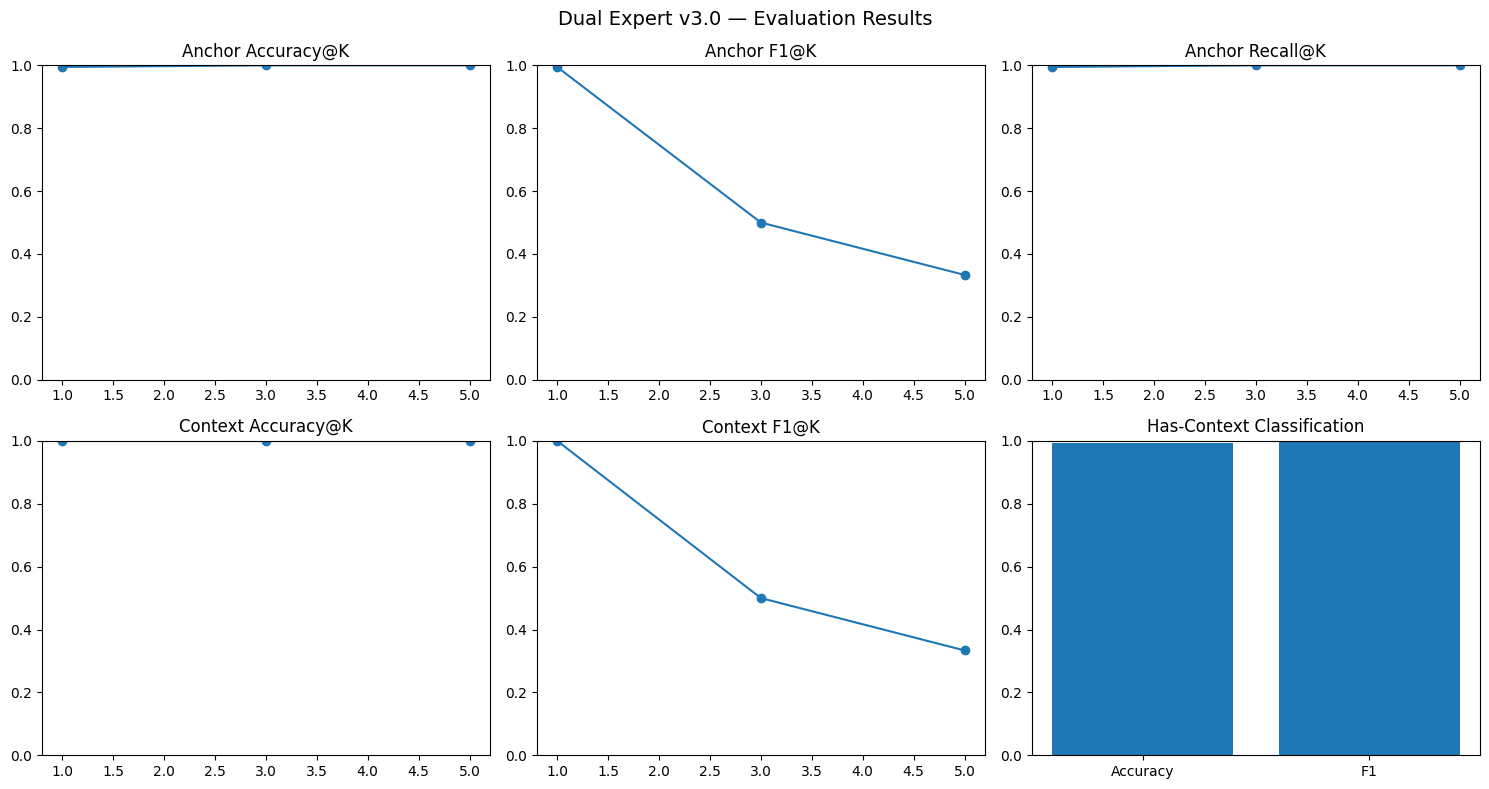

In [3]:
# ============================================================
# 📊 Dual Expert v3.0 — EVALUATION SCRIPT
# ============================================================

import os
import torch
import torch.nn.functional as F
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics import f1_score, accuracy_score


# ============================================================
# 🧠 Load Adapter (same as training)
# ============================================================

class DualExpertAdapter(torch.nn.Module):
    def __init__(self, input_dim=768, hidden_dim=256):
        super().__init__()

        self.anchor_adapter = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, input_dim)
        )

        self.context_adapter = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, input_dim)
        )

        self.has_context_head = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        anchor_emb = F.normalize(self.anchor_adapter(x), p=2, dim=1)
        context_emb = F.normalize(self.context_adapter(x), p=2, dim=1)
        has_ctx_logit = self.has_context_head(x).squeeze(-1)
        return anchor_emb, context_emb, has_ctx_logit


# ============================================================
# ⚙ CONFIG
# ============================================================

MODEL_PATH = "dual_expert_Advice_v3_0"
ADAPTER_PATH = os.path.join(MODEL_PATH, "dual_adapter_v3.pt")

DATA_FILE = "Advice.csv"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TOP_K = [1, 3, 5]


# ============================================================
# 🚀 Load Encoder + Adapter
# ============================================================

print("🔄 Loading SentenceTransformer...")
encoder = SentenceTransformer(MODEL_PATH).to(DEVICE)
encoder.eval()

try:
    emb_dim = encoder.get_sentence_embedding_dimension()
except:
    emb_dim = encoder.encode(["hi"], convert_to_tensor=True).shape[1]

print(f"📐 Embedding Dimension = {emb_dim}")

print("🔄 Loading Adapter...")
adapter = DualExpertAdapter(input_dim=emb_dim).to(DEVICE)
adapter.load_state_dict(torch.load(ADAPTER_PATH, map_location=DEVICE))
adapter.eval()


# ============================================================
# 📥 Load Dataset Anchors + Contexts
# ============================================================

df = pd.read_csv(DATA_FILE)
df = df[df["expert_label"] == "Advice"]

anchors = sorted(df["anchor"].unique())
contexts = sorted([
    c for c in df["context_name"].unique()
    if isinstance(c, str) and c.strip() != ""
])

print(f"📌 Found {len(anchors)} anchors")
print(f"📌 Found {len(contexts)} contexts")


# ============================================================
# ⚡ Pre-encode Anchors + Contexts
# ============================================================

print("⚡ Encoding anchors...")
with torch.no_grad():
    anchor_emb = encoder.encode(anchors, convert_to_tensor=True, device=DEVICE)
    anchor_emb = adapter.anchor_adapter(anchor_emb)
    anchor_emb = F.normalize(anchor_emb, p=2, dim=1)

print("⚡ Encoding contexts...")
if len(contexts) > 0:
    with torch.no_grad():
        context_emb = encoder.encode(contexts, convert_to_tensor=True, device=DEVICE)
        context_emb = adapter.context_adapter(context_emb)
        context_emb = F.normalize(context_emb, p=2, dim=1)
else:
    context_emb = None


# ============================================================
# 📊 Evaluation Utilities
# ============================================================

def topk_check(name_list, sim_scores, gold_name, k):
    top_k_idx = torch.topk(sim_scores, k).indices.tolist()
    top_k_names = [name_list[i] for i in top_k_idx]
    return gold_name in top_k_names


# ============================================================
# 📊 Main Evaluation
# ============================================================

def evaluate():
    print("\n🚀 Starting Evaluation...\n")

    results = {
        "anchor": {},
        "context": {},
        "hasctx": {}
    }

    with torch.no_grad():
        anchor_correct = {k: 0 for k in TOP_K}
        context_correct = {k: 0 for k in TOP_K}

        hasctx_true = []
        hasctx_pred = []

        total = len(df)
        ctx_total = len(df[df["has_context"] == 1])

        for _, row in df.iterrows():
            q = row["question"]
            gold_anchor = row["anchor"]
            gold_ctx = row["context_name"] if row["has_context"] == 1 else None
            gold_has_ctx = int(row["has_context"])

            q_emb = encoder.encode([q], convert_to_tensor=True, device=DEVICE)
            q_anchor, q_ctx, q_hasctx = adapter(q_emb)

            # ---------- ANCHOR ----------
            sim_anchor = (q_anchor @ anchor_emb.T)[0]
            for k in TOP_K:
                if topk_check(anchors, sim_anchor, gold_anchor, k):
                    anchor_correct[k] += 1

            # ---------- CONTEXT ----------
            if gold_ctx and context_emb is not None:
                sim_ctx = (q_ctx @ context_emb.T)[0]
                for k in TOP_K:
                    if topk_check(contexts, sim_ctx, gold_ctx, k):
                        context_correct[k] += 1

            # ---------- HAS CONTEXT ----------
            prob = torch.sigmoid(q_hasctx).item()
            hasctx_pred.append(1 if prob >= 0.5 else 0)
            hasctx_true.append(gold_has_ctx)

    # ===============================
    # 📊 METRICS
    # ===============================

    for k in TOP_K:
        # ---- Anchor ----
        recall = anchor_correct[k] / total
        precision = recall / k
        f1 = 2 * precision * recall / (precision + recall + 1e-9)

        results["anchor"][k] = {
            "accuracy": recall,
            "recall": recall,
            "f1": f1
        }

        # ---- Context ----
        recall_ctx = context_correct[k] / max(ctx_total, 1)
        precision_ctx = recall_ctx / k
        f1_ctx = 2 * precision_ctx * recall_ctx / (precision_ctx + recall_ctx + 1e-9)

        results["context"][k] = {
            "accuracy": recall_ctx,
            "recall": recall_ctx,
            "f1": f1_ctx
        }

    # ---- Has-context ----
    results["hasctx"]["accuracy"] = accuracy_score(hasctx_true, hasctx_pred)
    results["hasctx"]["f1"] = f1_score(hasctx_true, hasctx_pred)

    return results
import matplotlib.pyplot as plt

def visualize_results(results, save_path=None):
    ks = sorted(results["anchor"].keys())

    # ---------- Anchor ----------
    anchor_acc = [results["anchor"][k]["accuracy"] for k in ks]
    anchor_f1  = [results["anchor"][k]["f1"] for k in ks]
    anchor_rec = [results["anchor"][k]["recall"] for k in ks]

    # ---------- Context ----------
    ctx_acc = [results["context"][k]["accuracy"] for k in ks]
    ctx_f1  = [results["context"][k]["f1"] for k in ks]

    # ---------- Has-context ----------
    hasctx_acc = results["hasctx"]["accuracy"]
    hasctx_f1  = results["hasctx"]["f1"]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))

    # Anchor
    axes[0, 0].plot(ks, anchor_acc, marker="o")
    axes[0, 0].set_title("Anchor Accuracy@K")
    axes[0, 0].set_ylim(0, 1)

    axes[0, 1].plot(ks, anchor_f1, marker="o")
    axes[0, 1].set_title("Anchor F1@K")
    axes[0, 1].set_ylim(0, 1)

    axes[0, 2].plot(ks, anchor_rec, marker="o")
    axes[0, 2].set_title("Anchor Recall@K")
    axes[0, 2].set_ylim(0, 1)

    # Context
    axes[1, 0].plot(ks, ctx_acc, marker="o")
    axes[1, 0].set_title("Context Accuracy@K")
    axes[1, 0].set_ylim(0, 1)

    axes[1, 1].plot(ks, ctx_f1, marker="o")
    axes[1, 1].set_title("Context F1@K")
    axes[1, 1].set_ylim(0, 1)

    # Has-context
    axes[1, 2].bar(["Accuracy", "F1"], [hasctx_acc, hasctx_f1])
    axes[1, 2].set_ylim(0, 1)
    axes[1, 2].set_title("Has-Context Classification")

    plt.suptitle("Dual Expert v3.0 — Evaluation Results", fontsize=14)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()



if __name__ == "__main__":
    results = evaluate()
    visualize_results(
        results,
        save_path="dual_expert_v3_evaluation.png"
    )



🔄 Loading SentenceTransformer...
📐 Embedding dimension = 768
🔄 Loading Dual Expert adapter...
📌 Loaded 408 anchors from anchors.csv
📌 Loaded 5754 evaluation samples
⚡ Encoding anchor candidates...


Batches:   0%|          | 0/13 [00:00<?, ?it/s]

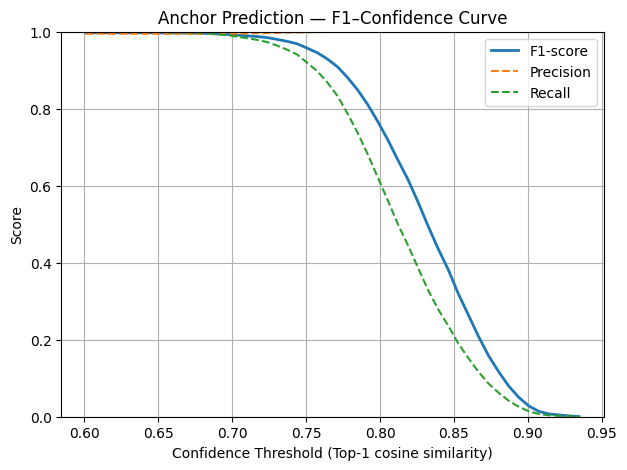

💾 Saved figure to anchor_f1_confidence_curve.png


In [5]:
# ============================================================
# 📊 Anchor F1–Confidence Curve — Dual Expert v3.0
#  - Anchor candidates: anchors.csv
#  - Ground truth: Advice.csv (column: anchor)
#  - Confidence = Top-1 cosine similarity
# ============================================================

import os
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics import precision_score, recall_score, f1_score

# ============================================================
# ⚙ CONFIG
# ============================================================

MODEL_PATH = "dual_expert_Advice_v3_0"
ADAPTER_PATH = os.path.join(MODEL_PATH, "dual_adapter_v3.pt")

ANCHOR_FILE = "anchors.csv"
DATA_FILE = "Advice.csv"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_THRESHOLDS = 50

# ============================================================
# 🧠 Dual Expert Adapter
# ============================================================

class DualExpertAdapter(torch.nn.Module):
    def __init__(self, input_dim=768, hidden_dim=256):
        super().__init__()

        self.anchor_adapter = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, input_dim)
        )

        self.context_adapter = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, input_dim)
        )

        self.has_context_head = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        anchor_emb = F.normalize(self.anchor_adapter(x), p=2, dim=1)
        context_emb = F.normalize(self.context_adapter(x), p=2, dim=1)
        has_ctx_logit = self.has_context_head(x).squeeze(-1)
        return anchor_emb, context_emb, has_ctx_logit


# ============================================================
# 🚀 Load Encoder + Adapter
# ============================================================

print("🔄 Loading SentenceTransformer...")
encoder = SentenceTransformer(MODEL_PATH).to(DEVICE)
encoder.eval()

emb_dim = encoder.get_sentence_embedding_dimension()
print(f"📐 Embedding dimension = {emb_dim}")

print("🔄 Loading Dual Expert adapter...")
adapter = DualExpertAdapter(input_dim=emb_dim).to(DEVICE)
adapter.load_state_dict(torch.load(ADAPTER_PATH, map_location=DEVICE))
adapter.eval()

# ============================================================
# 📥 Load anchors from anchors.csv
# ============================================================

df_anchor = pd.read_csv(ANCHOR_FILE)
anchors = df_anchor["name"].dropna().astype(str).tolist()

print(f"📌 Loaded {len(anchors)} anchors from anchors.csv")

# ============================================================
# 📥 Load evaluation data
# ============================================================

df = pd.read_csv(DATA_FILE)
df = df[df["expert_label"] == "Advice"]

print(f"📌 Loaded {len(df)} evaluation samples")

# ============================================================
# ⚡ Encode anchor candidates (INFERENCE MODE SAFE)
# ============================================================

print("⚡ Encoding anchor candidates...")
with torch.no_grad():
    anchor_emb = encoder.encode(
        anchors,
        convert_to_tensor=True,
        device=DEVICE,
        show_progress_bar=True
    )
    anchor_emb = adapter.anchor_adapter(anchor_emb)
    anchor_emb = F.normalize(anchor_emb, p=2, dim=1)

# ============================================================
# 📊 Collect confidence + correctness
# ============================================================

def collect_anchor_confidence():
    y_true = []
    y_score = []

    with torch.no_grad():
        for _, row in df.iterrows():
            question = row["question"]
            gold_anchor = str(row["anchor"])

            q_emb = encoder.encode(
                [question],
                convert_to_tensor=True,
                device=DEVICE
            )

            q_anchor, _, _ = adapter(q_emb)

            # cosine similarity with all anchors.csv
            sim = (q_anchor @ anchor_emb.T)[0]

            top1_idx = torch.argmax(sim).item()
            top1_score = sim[top1_idx].item()
            pred_anchor = anchors[top1_idx]

            y_true.append(1 if pred_anchor == gold_anchor else 0)
            y_score.append(top1_score)

    return np.array(y_true), np.array(y_score)

# ============================================================
# 📈 Compute F1–Confidence curve
# ============================================================

def compute_f1_confidence_curve(y_true, y_score, num_points=NUM_THRESHOLDS):
    thresholds = np.linspace(y_score.min(), y_score.max(), num_points)

    precisions, recalls, f1s = [], [], []

    for t in thresholds:
        y_pred = (y_score >= t).astype(int)

        if y_pred.sum() == 0:
            precisions.append(0.0)
            recalls.append(0.0)
            f1s.append(0.0)
            continue

        precisions.append(precision_score(y_true, y_pred))
        recalls.append(recall_score(y_true, y_pred))
        f1s.append(f1_score(y_true, y_pred))

    return thresholds, precisions, recalls, f1s

# ============================================================
# 📊 Visualization (THESIS-READY)
# ============================================================

def plot_anchor_f1_confidence(thresholds, f1s, precisions, recalls,
                              save_path="anchor_f1_confidence_curve.png"):
    plt.figure(figsize=(7, 5))

    plt.plot(thresholds, f1s, label="F1-score", linewidth=2)
    plt.plot(thresholds, precisions, "--", label="Precision")
    plt.plot(thresholds, recalls, "--", label="Recall")

    plt.xlabel("Confidence Threshold (Top-1 cosine similarity)")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.title("Anchor Prediction — F1–Confidence Curve")
    plt.legend()
    plt.grid(True)

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"💾 Saved figure to {save_path}")

# ============================================================
# ▶️ MAIN
# ============================================================

if __name__ == "__main__":
    y_true, y_score = collect_anchor_confidence()

    thresholds, P, R, F1 = compute_f1_confidence_curve(y_true, y_score)

    plot_anchor_f1_confidence(
        thresholds, F1, P, R,
        save_path="anchor_f1_confidence_curve.png"
    )


🔄 Loading encoder...


Batches:   0%|          | 0/13 [00:00<?, ?it/s]

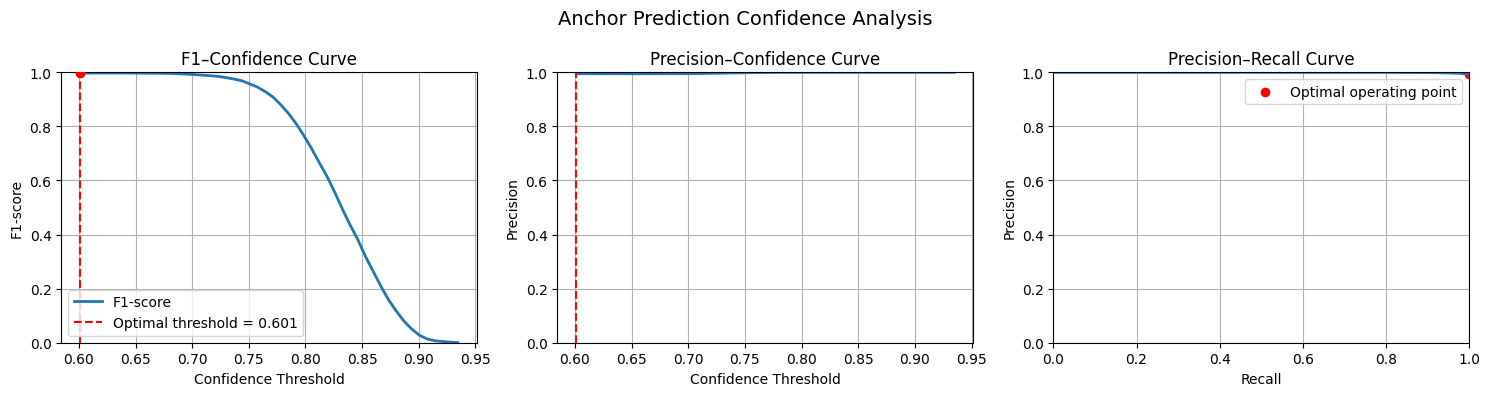

📌 Optimal Threshold Summary
  Threshold = 0.6012
  F1-score  = 0.9974
💾 Saved figure to anchor_confidence_curves.png


In [10]:
# ============================================================
# 📊 Anchor Confidence Curves — Dual Expert v3.0
#  - F1–Confidence
#  - Precision–Confidence
#  - Precision–Recall
# ============================================================

import os
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics import precision_score, recall_score, f1_score

# ============================================================
# ⚙ CONFIG
# ============================================================

MODEL_PATH = "dual_expert_Advice_v3_0"
ADAPTER_PATH = os.path.join(MODEL_PATH, "dual_adapter_v3.pt")

ANCHOR_FILE = "anchors.csv"
DATA_FILE = "Advice.csv"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_THRESHOLDS = 50

# ============================================================
# 🧠 Dual Expert Adapter (Anchor only)
# ============================================================

class DualExpertAdapter(torch.nn.Module):
    def __init__(self, input_dim=768, hidden_dim=256):
        super().__init__()

        self.anchor_adapter = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, input_dim)
        )

        self.context_adapter = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, input_dim)
        )

        self.has_context_head = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        anchor_emb = F.normalize(self.anchor_adapter(x), p=2, dim=1)
        context_emb = F.normalize(self.context_adapter(x), p=2, dim=1)
        has_ctx_logit = self.has_context_head(x).squeeze(-1)
        return anchor_emb, context_emb, has_ctx_logit



# ============================================================
# 🚀 Load Encoder + Adapter
# ============================================================

print("🔄 Loading encoder...")
encoder = SentenceTransformer(MODEL_PATH).to(DEVICE)
encoder.eval()

emb_dim = encoder.get_sentence_embedding_dimension()

adapter = DualExpertAdapter(emb_dim).to(DEVICE)
adapter.load_state_dict(torch.load(ADAPTER_PATH, map_location=DEVICE))
adapter.eval()

# ============================================================
# 📥 Load Anchors
# ============================================================

anchors = pd.read_csv(ANCHOR_FILE)["name"].dropna().astype(str).tolist()

# ============================================================
# 📥 Load Evaluation Data
# ============================================================

df = pd.read_csv(DATA_FILE)
df = df[df["expert_label"] == "Advice"]

# ============================================================
# ⚡ Encode Anchors (SAFE)
# ============================================================

with torch.no_grad():
    base_anchor_emb = encoder.encode(
        anchors,
        convert_to_tensor=True,
        device=DEVICE,
        show_progress_bar=True
    )

    anchor_emb, _, _ = adapter(base_anchor_emb)


# ============================================================
# 📊 Collect confidence + correctness
# ============================================================

def collect_anchor_scores():
    y_true, y_score = [], []

    with torch.no_grad():
        for _, row in df.iterrows():
            q = row["question"]
            gold_anchor = str(row["anchor"])

            q_emb = encoder.encode(
                [q],
                convert_to_tensor=True,
                device=DEVICE
            )

            # ✅ UNPACK OUTPUT
            q_anchor, _, _ = adapter(q_emb)

            # cosine similarity with anchor candidates
            sim = (q_anchor @ anchor_emb.T)[0]
            idx = torch.argmax(sim).item()

            y_score.append(sim[idx].item())
            y_true.append(1 if anchors[idx] == gold_anchor else 0)

    return np.array(y_true), np.array(y_score)

# ============================================================
# 📈 Compute Curves
# ============================================================

def compute_curves(y_true, y_score):
    thresholds = np.linspace(y_score.min(), y_score.max(), NUM_THRESHOLDS)

    P, R, F1 = [], [], []

    for t in thresholds:
        y_pred = (y_score >= t).astype(int)

        if y_pred.sum() == 0:
            P.append(0.0)
            R.append(0.0)
            F1.append(0.0)
            continue

        p = precision_score(y_true, y_pred)
        r = recall_score(y_true, y_pred)
        f = f1_score(y_true, y_pred)

        P.append(p)
        R.append(r)
        F1.append(f)

    return thresholds, np.array(P), np.array(R), np.array(F1)

# ============================================================
# 🎨 Visualization (THESIS-READY)
# ============================================================

def visualize_curves(thresholds, P, R, F1,
                     save_path="anchor_confidence_curves.png"):

    # 🔥 Optimal threshold
    best_idx = np.argmax(F1)
    best_t = thresholds[best_idx]
    best_f1 = F1[best_idx]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # ================= F1–Confidence =================
    axes[0].plot(thresholds, F1, linewidth=2, label="F1-score")
    axes[0].axvline(
        best_t, color="red", linestyle="--",
        label=f"Optimal threshold = {best_t:.3f}"
    )
    axes[0].scatter(best_t, best_f1, color="red", zorder=5)

    axes[0].set_title("F1–Confidence Curve")
    axes[0].set_xlabel("Confidence Threshold")
    axes[0].set_ylabel("F1-score")
    axes[0].set_ylim(0, 1)
    axes[0].grid(True)
    axes[0].legend()

    # ================= Precision–Confidence =================
    axes[1].plot(thresholds, P, linewidth=2)
    axes[1].axvline(best_t, color="red", linestyle="--")

    axes[1].set_title("Precision–Confidence Curve")
    axes[1].set_xlabel("Confidence Threshold")
    axes[1].set_ylabel("Precision")
    axes[1].set_ylim(0, 1)
    axes[1].grid(True)

    # ================= Precision–Recall =================
    axes[2].plot(R, P, linewidth=2)
    axes[2].scatter(
        R[best_idx], P[best_idx],
        color="red", label="Optimal operating point"
    )

    axes[2].set_title("Precision–Recall Curve")
    axes[2].set_xlabel("Recall")
    axes[2].set_ylabel("Precision")
    axes[2].set_xlim(0, 1)
    axes[2].set_ylim(0, 1)
    axes[2].grid(True)
    axes[2].legend()

    plt.suptitle("Anchor Prediction Confidence Analysis", fontsize=14)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("📌 Optimal Threshold Summary")
    print(f"  Threshold = {best_t:.4f}")
    print(f"  F1-score  = {best_f1:.4f}")
    print(f"💾 Saved figure to {save_path}")


# ============================================================
# ▶️ MAIN
# ============================================================

if __name__ == "__main__":
    y_true, y_score = collect_anchor_scores()
    thresholds, P, R, F1 = compute_curves(y_true, y_score)
    visualize_curves(thresholds, P, R, F1)


🔄 Loading encoder...
🔄 Loading adapter...
📌 Context samples = 4795
📌 Context candidates = 5
⚡ Encoding context candidates...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

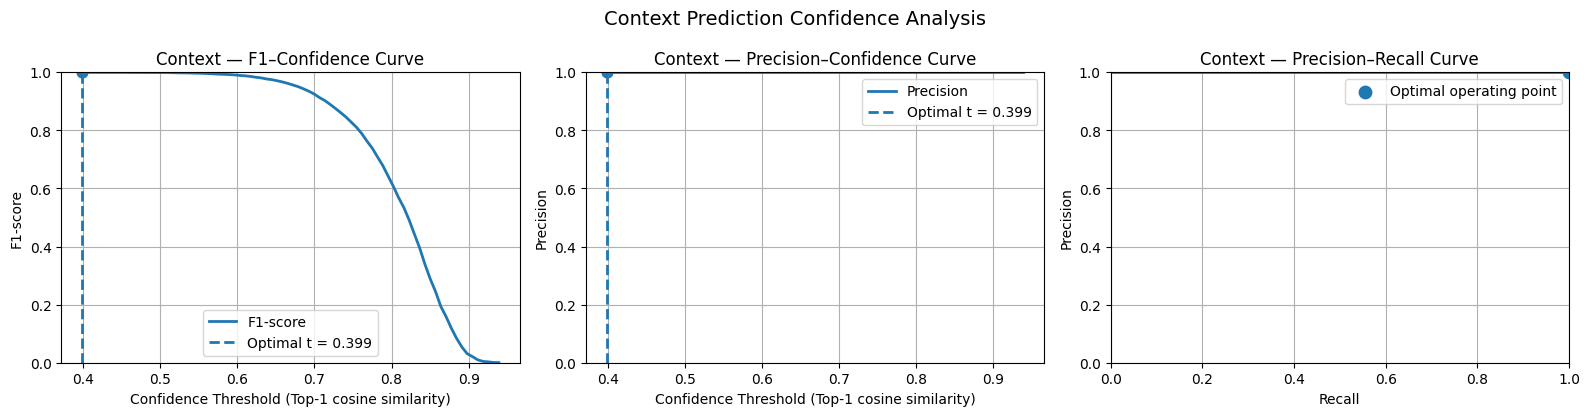

✅ Saved to: context_confidence_curves.png
⭐ Optimal threshold t=0.399 | P=1.0000 R=1.0000 F1=1.0000


In [11]:
# ============================================================
# 📊 Context Confidence Curves — Dual Expert v3.0
#  - F1–Confidence
#  - Precision–Confidence
#  - Precision–Recall
#  - Optimal threshold (max F1)
# ============================================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics import precision_score, recall_score, f1_score


# =========================
# ⚙ CONFIG
# =========================
MODEL_PATH = "dual_expert_Advice_v3_0"
ADAPTER_PATH = os.path.join(MODEL_PATH, "dual_adapter_v3.pt")

DATA_FILE = "Advice.csv"
CONTEXT_FILE = "contexts.csv"   # khuyến nghị dùng file này

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_THRESHOLDS = 80  # mịn hơn 50


# =========================
# 🧠 Adapter
# =========================
class DualExpertAdapter(torch.nn.Module):
    def __init__(self, input_dim=768, hidden_dim=256):
        super().__init__()
        self.anchor_adapter = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, input_dim),
        )
        self.context_adapter = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, input_dim),
        )
        self.has_context_head = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        anchor_emb = F.normalize(self.anchor_adapter(x), p=2, dim=1)
        context_emb = F.normalize(self.context_adapter(x), p=2, dim=1)
        has_ctx_logit = self.has_context_head(x).squeeze(-1)
        return anchor_emb, context_emb, has_ctx_logit


# =========================
# 🚀 Load encoder + adapter
# =========================
print("🔄 Loading encoder...")
encoder = SentenceTransformer(MODEL_PATH).to(DEVICE).eval()
emb_dim = encoder.get_sentence_embedding_dimension()

print("🔄 Loading adapter...")
adapter = DualExpertAdapter(input_dim=emb_dim).to(DEVICE)
adapter.load_state_dict(torch.load(ADAPTER_PATH, map_location=DEVICE))
adapter.eval()


# =========================
# 📥 Load data (ONLY has_context=1)
# =========================
df = pd.read_csv(DATA_FILE)
df = df[df["expert_label"] == "Advice"].copy()
df["has_context"] = df["has_context"].fillna(0).astype(int)
df["context_name"] = df["context_name"].fillna("").astype(str)

df_ctx = df[df["has_context"] == 1].copy()
df_ctx = df_ctx[df_ctx["context_name"].str.strip() != ""]

print(f"📌 Context samples = {len(df_ctx)}")


# =========================
# 📥 Load context candidates
# =========================
if os.path.exists(CONTEXT_FILE):
    contexts = pd.read_csv(CONTEXT_FILE)["name"].dropna().astype(str).tolist()
else:
    # fallback: lấy unique từ data
    contexts = sorted(df_ctx["context_name"].unique().tolist())

print(f"📌 Context candidates = {len(contexts)}")


# =========================
# ⚡ Encode context candidates (q_ctx space)
# =========================
print("⚡ Encoding context candidates...")
with torch.no_grad():
    ctx_raw = encoder.encode(
        contexts,
        convert_to_tensor=True,
        device=DEVICE,
        show_progress_bar=True,
    )
    # IMPORTANT: dùng context_adapter (không gọi adapter() vì nó trả tuple)
    ctx_emb = adapter.context_adapter(ctx_raw)
    ctx_emb = F.normalize(ctx_emb, p=2, dim=1)


# =========================
# 📊 Collect confidence + correctness (Top-1 cosine sim)
# =========================
def collect_context_scores():
    y_true = []
    y_score = []

    with torch.no_grad():
        for _, row in df_ctx.iterrows():
            q = str(row["question"])
            gold_ctx = str(row["context_name"]).strip()

            q_raw = encoder.encode([q], convert_to_tensor=True, device=DEVICE)
            _, q_ctx, _ = adapter(q_raw)  # lấy q_ctx

            sim = (q_ctx @ ctx_emb.T)[0]  # (num_contexts,)
            top1_idx = int(torch.argmax(sim).item())
            top1_score = float(sim[top1_idx].item())
            pred_ctx = contexts[top1_idx]

            y_true.append(1 if pred_ctx == gold_ctx else 0)
            y_score.append(top1_score)

    return np.array(y_true), np.array(y_score)


# =========================
# 📈 Compute curves
# =========================
def compute_curves(y_true, y_score, num_thresholds=NUM_THRESHOLDS):
    # threshold sweep theo miền score thật
    thresholds = np.linspace(y_score.min(), y_score.max(), num_thresholds)

    P, R, F1 = [], [], []
    for t in thresholds:
        # “accept” nếu confidence >= t
        y_pred = (y_score >= t).astype(int)

        if y_pred.sum() == 0:
            P.append(0.0); R.append(0.0); F1.append(0.0)
            continue

        p = precision_score(y_true, y_pred, zero_division=0)
        r = recall_score(y_true, y_pred, zero_division=0)
        f = f1_score(y_true, y_pred, zero_division=0)
        P.append(p); R.append(r); F1.append(f)

    P = np.array(P); R = np.array(R); F1 = np.array(F1)

    # optimal threshold = max F1 (nếu nhiều điểm bằng nhau -> lấy threshold nhỏ nhất)
    best_idx = int(np.argmax(F1))
    best_t = float(thresholds[best_idx])
    best_p = float(P[best_idx])
    best_r = float(R[best_idx])
    best_f = float(F1[best_idx])

    return thresholds, P, R, F1, (best_t, best_p, best_r, best_f)


# =========================
# 🎨 Plot (thesis-ready)
# =========================
def plot_context_curves(thresholds, P, R, F1, best, save_path="context_confidence_curves.png"):
    best_t, best_p, best_r, best_f = best

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

    # --- F1–Confidence ---
    axes[0].plot(thresholds, F1, linewidth=2, label="F1-score")
    axes[0].axvline(best_t, linestyle="--", linewidth=2, label=f"Optimal t = {best_t:.3f}")
    axes[0].scatter([best_t], [best_f], s=60)
    axes[0].set_title("Context — F1–Confidence Curve")
    axes[0].set_xlabel("Confidence Threshold (Top-1 cosine similarity)")
    axes[0].set_ylabel("F1-score")
    axes[0].set_ylim(0, 1)
    axes[0].grid(True)
    axes[0].legend()

    # --- Precision–Confidence ---
    axes[1].plot(thresholds, P, linewidth=2, label="Precision")
    axes[1].axvline(best_t, linestyle="--", linewidth=2, label=f"Optimal t = {best_t:.3f}")
    axes[1].scatter([best_t], [best_p], s=60)
    axes[1].set_title("Context — Precision–Confidence Curve")
    axes[1].set_xlabel("Confidence Threshold (Top-1 cosine similarity)")
    axes[1].set_ylabel("Precision")
    axes[1].set_ylim(0, 1)
    axes[1].grid(True)
    axes[1].legend()

    # --- Precision–Recall ---
    axes[2].plot(R, P, linewidth=2)
    axes[2].scatter([best_r], [best_p], s=80, label="Optimal operating point")
    axes[2].set_title("Context — Precision–Recall Curve")
    axes[2].set_xlabel("Recall")
    axes[2].set_ylabel("Precision")
    axes[2].set_xlim(0, 1)
    axes[2].set_ylim(0, 1)
    axes[2].grid(True)
    axes[2].legend()

    plt.suptitle("Context Prediction Confidence Analysis", fontsize=14)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"✅ Saved to: {save_path}")
    print(f"⭐ Optimal threshold t={best_t:.3f} | P={best_p:.4f} R={best_r:.4f} F1={best_f:.4f}")


# =========================
# ▶️ MAIN
# =========================
if __name__ == "__main__":
    y_true, y_score = collect_context_scores()
    thresholds, P, R, F1, best = compute_curves(y_true, y_score)
    plot_context_curves(thresholds, P, R, F1, best)
